In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
%matplotlib inline


In [4]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Height vs Weight')

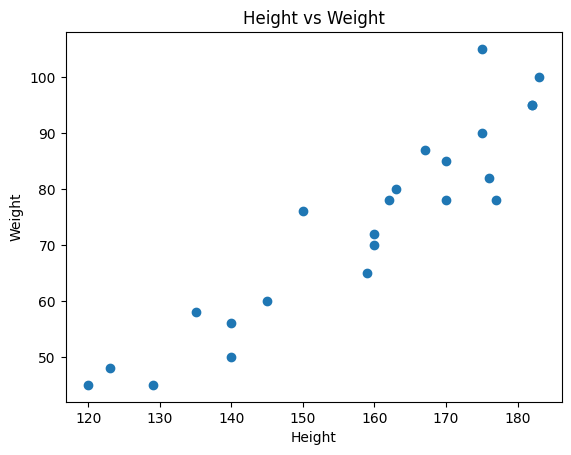

In [7]:
# Scatter Plot
plt.scatter(df['Height'] ,df['Weight'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')

In [8]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


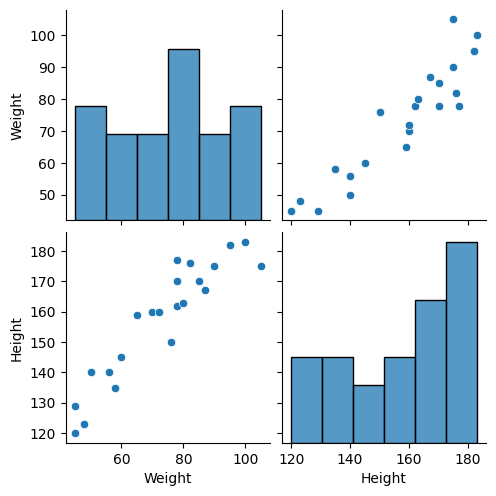

In [10]:
sns.pairplot(df)

In [15]:
# Independent and Dependent Features
X = df[['Weight']]  ### Independent Feature should be in 2D
y = df['Height']    ### Dependent Feature can be in 1D
X.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [16]:
### Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [18]:
# Standardization 
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [20]:
X_test = scaler.transform(X_test)
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [23]:
# Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression
regressor = LinearRegression(n_jobs=-1)

In [24]:
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
print("Coefficient:", regressor.coef_)
print("Intercept:", regressor.intercept_)

Coefficient: [17.2982057]
Intercept: 156.47058823529412


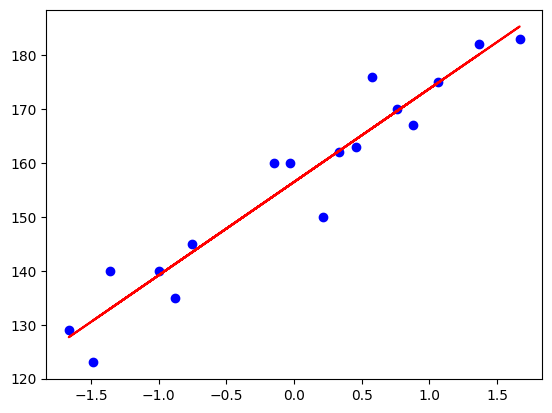

In [29]:
# Plot traning data plot best fit line
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, regressor.predict(X_train), color='red')

### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =156.470 + 17.29(X_test)

In [30]:
# Predicting on Test Data
y_pred = regressor.predict(X_test)

In [31]:
# Perfomance Matrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [32]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 114.84069295228699
Mean Absolute Error: 9.66512588679501
R2 Score: 0.7360826717981276
Root Mean Squared Error: 10.716374991212605


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [34]:
# Adjusted R2 Score
def adjusted_r2_score(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)
adjusted_r2_score(r2, X_test.shape[0], X_test.shape[1])

0.6701033397476595

In [36]:
## OLS Regression Summary
import statsmodels.api as sm

In [37]:
model = sm.OLS(y_train, X_train).fit()

In [40]:
prediction = model.predict(X_train)
print(prediction)

[-15.16409156  28.84875956   5.79440897 -25.64334183  23.60913442
 -28.78711691 -13.06824151  -2.58899124   3.69855892 -23.54749178
 -17.25994162  -0.49314119  18.36950929   9.98610908  13.12988416
  15.22573421   7.89025902]


In [41]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Wed, 31 Dec 2025   Prob (F-statistic):                       0.664
Time:                        00:15:09   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [45]:
## Predicting on a new data point
regressor.predict(scaler.transform([[78]]))  # Predicting height for weight 150

d:\Krish_Naik\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([162.26499721])